# Model Training & Evaluation
## Nairobi House Price Prediction

This notebook covers training, tuning, and evaluating machine learning models for house price prediction.

In [17]:
pip install xgboost lightgbm matplotlib seaborn pandas numpy scikit-learn ipykernel

Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries & Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [19]:
# Load the demo dataset and prepare it (same as Feature_Engineering notebook)
df = pd.read_csv('../data/raw/all_listings_demo.csv')

# Data cleaning
df_clean = df.copy()
df_clean['amenities'] = df_clean['amenities'].fillna('None')
critical_cols = ['price_kes', 'bedrooms', 'bathrooms', 'size_sqft', 'location']
df_clean = df_clean.dropna(subset=critical_cols)
df_clean = df_clean.drop_duplicates(subset=['listing_id'])

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
df_encoded = df_clean.copy()
le_location = LabelEncoder()
df_encoded['location_encoded'] = le_location.fit_transform(df_encoded['location'])
le_property = LabelEncoder()
df_encoded['property_type_encoded'] = le_property.fit_transform(df_encoded['property_type'])

# Feature engineering
df_features = df_encoded.copy()
df_features['price_per_bed'] = df_features['price_kes'] / (df_features['bedrooms'] + 1)
df_features['price_per_sqft'] = df_features['price_kes'] / (df_features['size_sqft'] + 1)
df_features['bed_bath_ratio'] = df_features['bedrooms'] / (df_features['bathrooms'] + 1)
df_features['total_rooms'] = df_features['bedrooms'] + df_features['bathrooms']
df_features['has_amenities'] = (df_features['amenities'] != 'None').astype(int)
df_features['amenity_count'] = df_features['amenities'].apply(
    lambda x: len(str(x).split('|')) if x != 'None' else 0
)

# Select features for modeling
feature_cols = [
    'bedrooms', 'bathrooms', 'size_sqft',
    'location_encoded', 'property_type_encoded',
    'price_per_bed', 'price_per_sqft', 'bed_bath_ratio',
    'total_rooms', 'has_amenities', 'amenity_count'
]

from sklearn.model_selection import train_test_split
X = df_features[feature_cols].copy()
y = df_features['price_kes'].copy()

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data loaded and preprocessed successfully")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")
print(f"   Features: {len(feature_cols)}")

✅ Data loaded and preprocessed successfully
   Training samples: 640
   Test samples: 160
   Features: 11


## 2. Train Baseline Models

In [20]:
# Define evaluation function
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'Model': model_name,
        'R² Score': r2,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    }

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=15),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Train and evaluate baseline models
results = []
print("="*70)
print("🤖 TRAINING BASELINE MODELS")
print("="*70)

for name, model in models.items():
    print(f"\n📍 Training {name}...")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Evaluate
    train_result = evaluate_model(y_train, y_pred_train, f"{name} (Train)")
    test_result = evaluate_model(y_test, y_pred_test, f"{name} (Test)")
    
    results.append(test_result)
    
    print(f"✅ {name}")
    print(f"   Train R²: {train_result['R² Score']:.4f}")
    print(f"   Test R²: {test_result['R² Score']:.4f}")
    print(f"   Test MAE: KES {test_result['MAE']:,.0f}")
    print(f"   Test RMSE: KES {test_result['RMSE']:,.0f}")

# Create results dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("📊 BASELINE MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

🤖 TRAINING BASELINE MODELS

📍 Training Linear Regression...


✅ Linear Regression
   Train R²: 0.9406
   Test R²: 0.9323
   Test MAE: KES 5,363,531
   Test RMSE: KES 8,713,414

📍 Training Decision Tree...
✅ Decision Tree
   Train R²: 1.0000
   Test R²: 0.9503
   Test MAE: KES 2,015,474
   Test RMSE: KES 7,466,212

📍 Training Random Forest...
✅ Random Forest
   Train R²: 0.9968
   Test R²: 0.9844
   Test MAE: KES 1,656,674
   Test RMSE: KES 4,185,889

📍 Training Gradient Boosting...
✅ Gradient Boosting
   Train R²: 0.9993
   Test R²: 0.9892
   Test MAE: KES 1,463,152
   Test RMSE: KES 3,484,194

📍 Training XGBoost...
✅ XGBoost
   Train R²: 1.0000
   Test R²: 0.9871
   Test MAE: KES 1,498,017
   Test RMSE: KES 3,805,978

📍 Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037458 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 11
[LightGBM] [Info] Start 

## 3. Hyperparameter Tuning

In [21]:
print("="*70)
print("🔧 HYPERPARAMETER TUNING")
print("="*70)

# Tune Random Forest
print("\n📍 Tuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
print(f"✅ Best RF params: {rf_grid.best_params_}")
print(f"   Best CV R² Score: {rf_grid.best_score_:.4f}")

# Tune Gradient Boosting
print("\n📍 Tuning Gradient Boosting...")
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)
print(f"✅ Best GB params: {gb_grid.best_params_}")
print(f"   Best CV R² Score: {gb_grid.best_score_:.4f}")

# Store best models
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

print("\n✅ Tuning complete!")

🔧 HYPERPARAMETER TUNING

📍 Tuning Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/home/patel/Desktop/nairobi-house-price-prediction/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/patel/Desktop/nairobi-house-price-prediction/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/patel/Desktop/nairobi-house-price-prediction/venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

✅ Best RF params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
   Best CV R² Score: 0.9727

📍 Tuning Gradient Boosting...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
✅ Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
   Best CV R² Score: 0.9846

✅ Tuning complete!


## 4. Model Evaluation & Comparison

In [22]:
# Evaluate tuned models
tuned_models = {
    'Random Forest (Tuned)': best_rf,
    'Gradient Boosting (Tuned)': best_gb
}

tuned_results = []
print("="*70)
print("📊 TUNED MODEL EVALUATION")
print("="*70)

for name, model in tuned_models.items():
    print(f"\n📍 Evaluating {name}...")
    
    y_pred_test = model.predict(X_test)
    test_result = evaluate_model(y_test, y_pred_test, name)
    tuned_results.append(test_result)
    
    print(f"✅ {name}")
    print(f"   R²: {test_result['R² Score']:.4f}")
    print(f"   MAE: KES {test_result['MAE']:,.0f}")
    print(f"   RMSE: KES {test_result['RMSE']:,.0f}")
    print(f"   MAPE: {test_result['MAPE']:.2f}%")

# Combine all results
all_results = pd.concat([
    results_df,
    pd.DataFrame(tuned_results)
], ignore_index=True)

print("\n" + "="*70)
print("📊 ALL MODEL COMPARISON")
print("="*70)
print(all_results.to_string(index=False))

# Find best model
best_model_idx = all_results['R² Score'].idxmax()
best_model_name = all_results.loc[best_model_idx, 'Model']
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(all_results.loc[best_model_idx])

📊 TUNED MODEL EVALUATION

📍 Evaluating Random Forest (Tuned)...


✅ Random Forest (Tuned)
   R²: 0.9838
   MAE: KES 1,587,140
   RMSE: KES 4,267,368
   MAPE: 4.01%

📍 Evaluating Gradient Boosting (Tuned)...
✅ Gradient Boosting (Tuned)
   R²: 0.9903
   MAE: KES 1,388,575
   RMSE: KES 3,302,686
   MAPE: 3.77%

📊 ALL MODEL COMPARISON
                    Model  R² Score          MAE         RMSE      MAPE
 Linear Regression (Test)  0.932322 5.363531e+06 8.713414e+06 36.035626
     Decision Tree (Test)  0.950310 2.015474e+06 7.466212e+06  4.313869
     Random Forest (Test)  0.984381 1.656674e+06 4.185889e+06  4.022051
 Gradient Boosting (Test)  0.989179 1.463152e+06 3.484194e+06  4.839326
           XGBoost (Test)  0.987088 1.498017e+06 3.805978e+06  3.585253
          LightGBM (Test)  0.979554 1.938243e+06 4.789318e+06  4.492754
    Random Forest (Tuned)  0.983767 1.587140e+06 4.267368e+06  4.013958
Gradient Boosting (Tuned)  0.990277 1.388575e+06 3.302686e+06  3.774936

🏆 BEST MODEL: Gradient Boosting (Tuned)
Model       Gradient Boosting (Tuned)
R² Sco

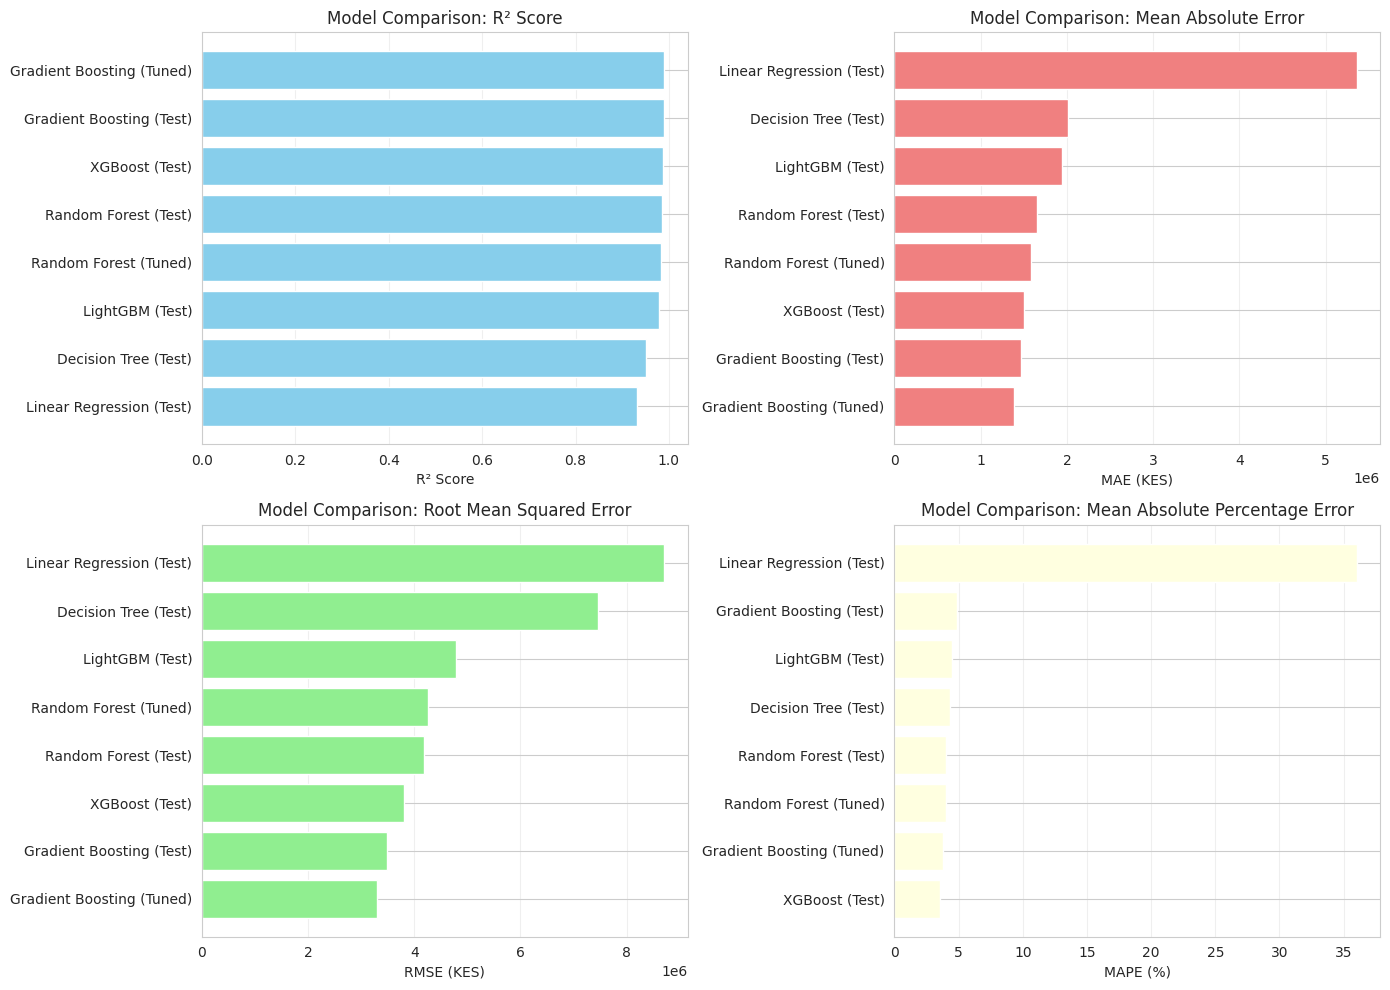

✅ Model comparison visualized


In [23]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² Score comparison
ax = axes[0, 0]
all_results_sorted = all_results.sort_values('R² Score', ascending=True)
ax.barh(all_results_sorted['Model'], all_results_sorted['R² Score'], color='skyblue')
ax.set_xlabel('R² Score')
ax.set_title('Model Comparison: R² Score')
ax.grid(True, alpha=0.3, axis='x')

# MAE comparison
ax = axes[0, 1]
all_results_sorted_mae = all_results.sort_values('MAE', ascending=True)
ax.barh(all_results_sorted_mae['Model'], all_results_sorted_mae['MAE'], color='lightcoral')
ax.set_xlabel('MAE (KES)')
ax.set_title('Model Comparison: Mean Absolute Error')
ax.grid(True, alpha=0.3, axis='x')

# RMSE comparison
ax = axes[1, 0]
all_results_sorted_rmse = all_results.sort_values('RMSE', ascending=True)
ax.barh(all_results_sorted_rmse['Model'], all_results_sorted_rmse['RMSE'], color='lightgreen')
ax.set_xlabel('RMSE (KES)')
ax.set_title('Model Comparison: Root Mean Squared Error')
ax.grid(True, alpha=0.3, axis='x')

# MAPE comparison
ax = axes[1, 1]
all_results_sorted_mape = all_results.sort_values('MAPE', ascending=True)
ax.barh(all_results_sorted_mape['Model'], all_results_sorted_mape['MAPE'], color='lightyellow')
ax.set_xlabel('MAPE (%)')
ax.set_title('Model Comparison: Mean Absolute Percentage Error')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✅ Model comparison visualized")

## 5. Feature Importance Analysis

🔍 FEATURE IMPORTANCE ANALYSIS


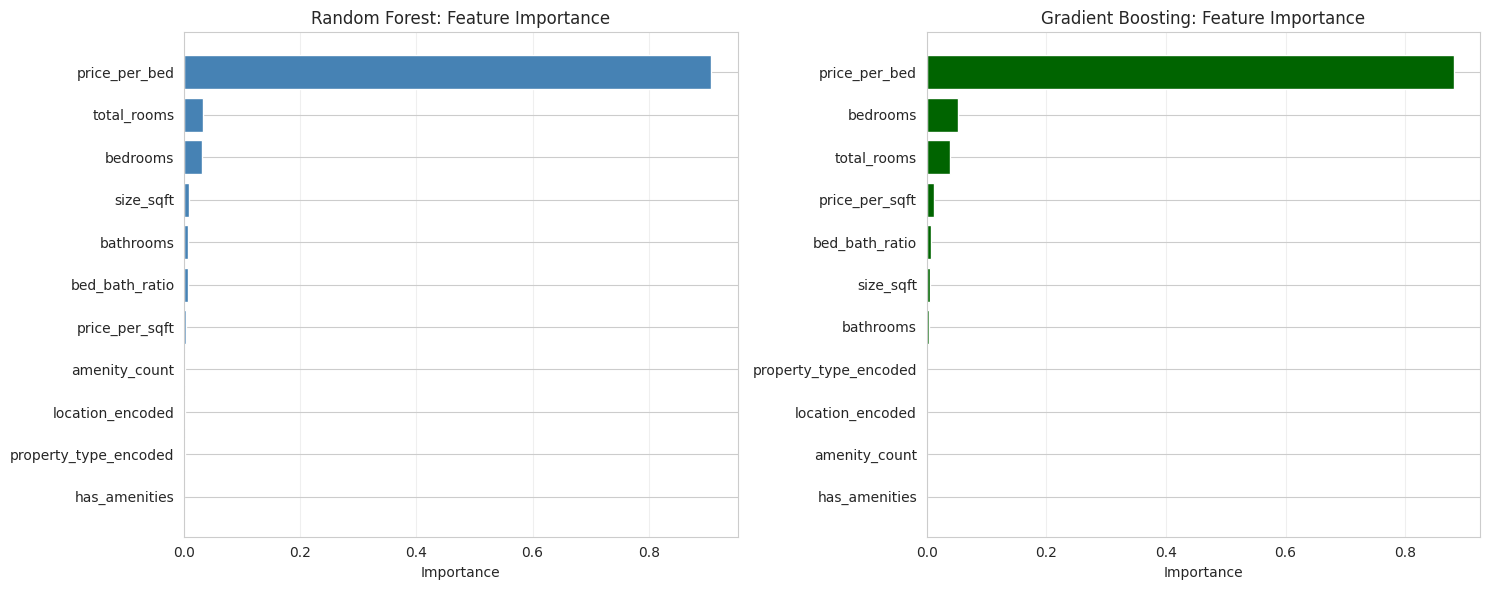


📊 Top 5 Features (Random Forest):
      Feature  Importance
    bathrooms    0.007080
    size_sqft    0.007889
     bedrooms    0.029933
  total_rooms    0.031692
price_per_bed    0.907625

📊 Top 5 Features (Gradient Boosting):
       Feature  Importance
bed_bath_ratio    0.007243
price_per_sqft    0.011726
   total_rooms    0.038929
      bedrooms    0.052378
 price_per_bed    0.880915


In [24]:
print("="*70)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Extract feature importance from tree-based models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

ax = axes[0]
ax.barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Random Forest: Feature Importance')
ax.grid(True, alpha=0.3, axis='x')

# Gradient Boosting feature importance
gb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_gb.feature_importances_
}).sort_values('Importance', ascending=True)

ax = axes[1]
ax.barh(gb_importance['Feature'], gb_importance['Importance'], color='darkgreen')
ax.set_xlabel('Importance')
ax.set_title('Gradient Boosting: Feature Importance')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Top 5 Features (Random Forest):")
print(rf_importance.tail(5).to_string(index=False))

print("\n📊 Top 5 Features (Gradient Boosting):")
print(gb_importance.tail(5).to_string(index=False))

## 6. Predictions on Test Set

In [25]:
# Select the best model for final predictions
# Determine which model is best
if best_model_name.startswith('Random Forest'):
    final_model = best_rf
elif best_model_name.startswith('Gradient Boosting'):
    final_model = best_gb
else:
    # Default to Random Forest if using a baseline model
    final_model = models['Random Forest']

# Make predictions
y_pred_final = final_model.predict(X_test)

print("="*70)
print("🎯 FINAL PREDICTIONS")
print("="*70)
print(f"\nUsing: {best_model_name}")

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_final,
    'Error': y_test.values - y_pred_final,
    'Absolute_Error': np.abs(y_test.values - y_pred_final),
    'Percentage_Error': np.abs((y_test.values - y_pred_final) / y_test.values) * 100
})

print("\n📊 Prediction Statistics:")
print(f"   Mean Absolute Error: KES {predictions_df['Absolute_Error'].mean():,.0f}")
print(f"   Median Absolute Error: KES {predictions_df['Absolute_Error'].median():,.0f}")
print(f"   Mean Percentage Error: {predictions_df['Percentage_Error'].mean():.2f}%")

print("\n📋 Sample Predictions (First 10):")
print(predictions_df.head(10).to_string(index=False))

🎯 FINAL PREDICTIONS

Using: Gradient Boosting (Tuned)

📊 Prediction Statistics:
   Mean Absolute Error: KES 1,388,575
   Median Absolute Error: KES 489,277
   Mean Percentage Error: 3.77%

📋 Sample Predictions (First 10):
   Actual    Predicted         Error  Absolute_Error  Percentage_Error
 30681346 3.092710e+07 -2.457579e+05    2.457579e+05          0.801001
 72231527 8.112288e+07 -8.891356e+06    8.891356e+06         12.309522
 76488976 6.746365e+07  9.025328e+06    9.025328e+06         11.799515
 17051936 1.675237e+07  2.995631e+05    2.995631e+05          1.756769
 47158509 4.665171e+07  5.068029e+05    5.068029e+05          1.074680
 65609832 6.688964e+07 -1.279810e+06    1.279810e+06          1.950638
163238468 1.355195e+08  2.771901e+07    2.771901e+07         16.980684
 61237567 5.808801e+07  3.149560e+06    3.149560e+06          5.143183
 46321056 4.555593e+07  7.651292e+05    7.651292e+05          1.651796
  6158134 6.464751e+06 -3.066167e+05    3.066167e+05          4.9790

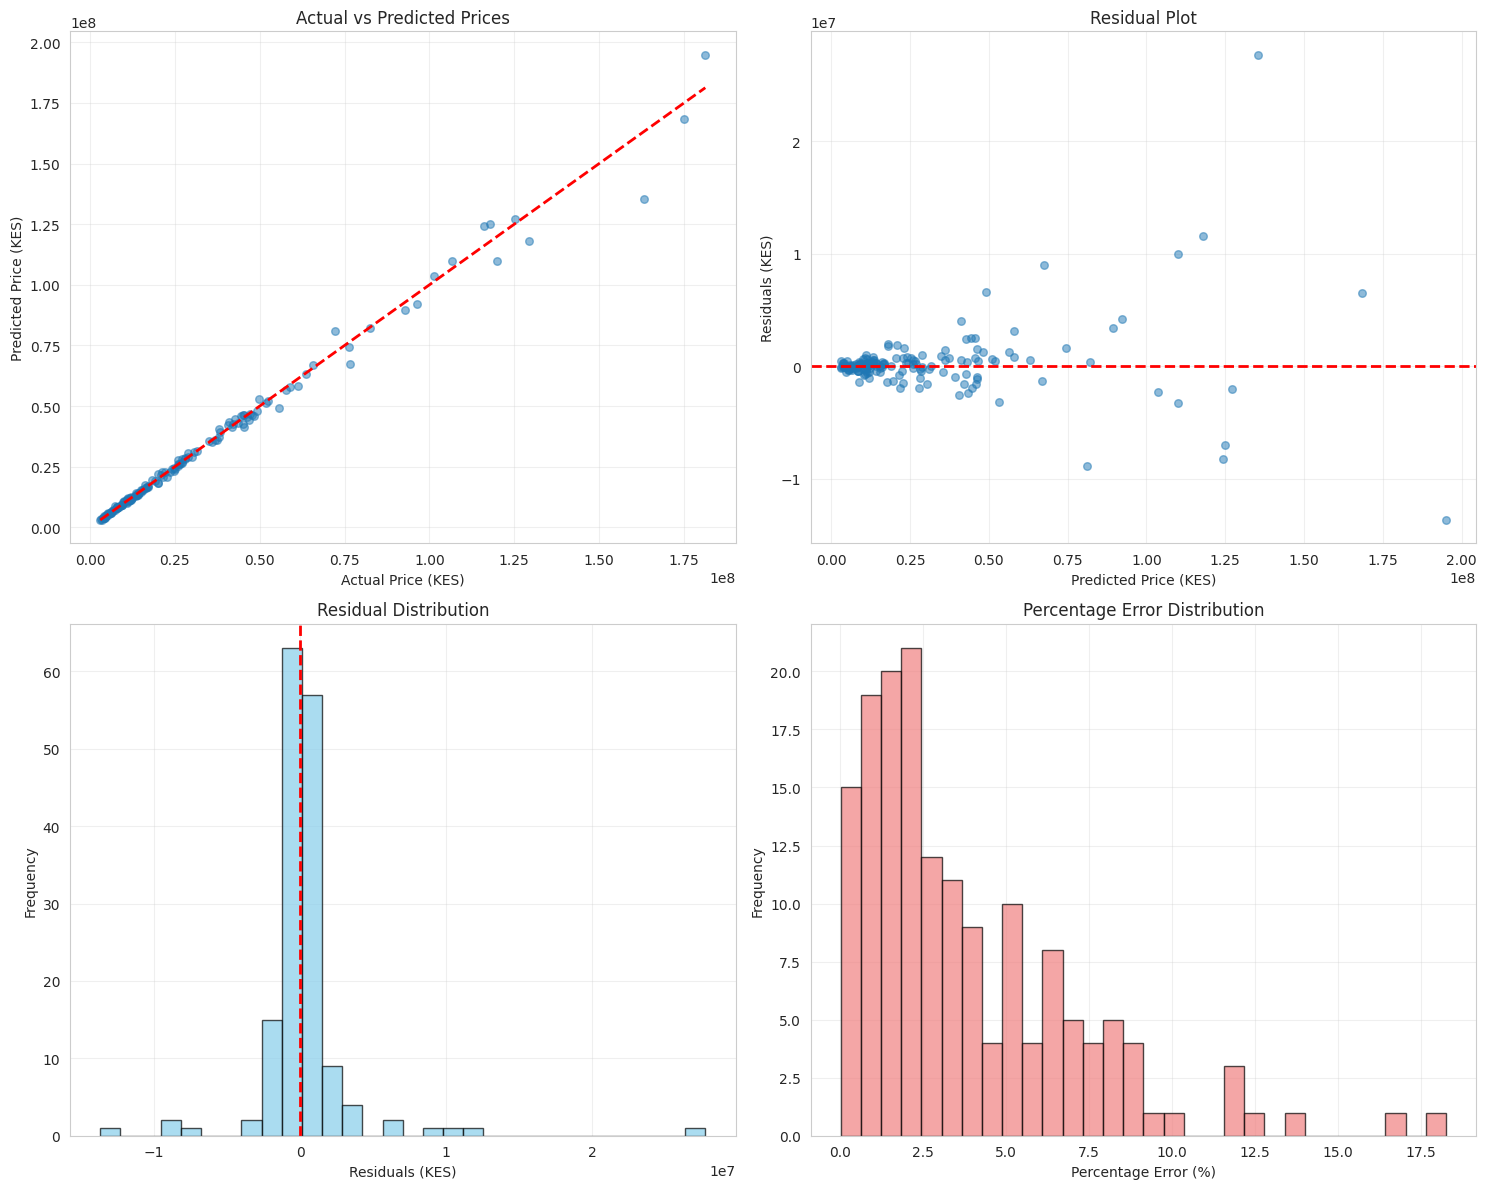

✅ Predictions visualized


In [26]:
# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Actual vs Predicted scatter plot
ax = axes[0, 0]
ax.scatter(y_test, y_pred_final, alpha=0.5, s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price (KES)')
ax.set_ylabel('Predicted Price (KES)')
ax.set_title('Actual vs Predicted Prices')
ax.grid(True, alpha=0.3)

# Residuals plot
ax = axes[0, 1]
residuals = y_test.values - y_pred_final
ax.scatter(y_pred_final, residuals, alpha=0.5, s=30)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Price (KES)')
ax.set_ylabel('Residuals (KES)')
ax.set_title('Residual Plot')
ax.grid(True, alpha=0.3)

# Error distribution
ax = axes[1, 0]
ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax.set_xlabel('Residuals (KES)')
ax.set_ylabel('Frequency')
ax.set_title('Residual Distribution')
ax.axvline(x=0, color='r', linestyle='--', lw=2)
ax.grid(True, alpha=0.3)

# Percentage error distribution
ax = axes[1, 1]
ax.hist(predictions_df['Percentage_Error'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
ax.set_xlabel('Percentage Error (%)')
ax.set_ylabel('Frequency')
ax.set_title('Percentage Error Distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Predictions visualized")

## 7. Save Trained Model

In [27]:
import os
import pickle
from datetime import datetime

print("="*70)
print("💾 SAVING TRAINED MODEL")
print("="*70)

# Create models directory if it doesn't exist
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save the best model as Pickle (.pkl)
pkl_path = os.path.join(model_dir, f'best_model_{timestamp}.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f"\n✅ Best model saved: {pkl_path}")

# Also save as model.pkl for easy access
pkl_simple_path = os.path.join(model_dir, 'model.pkl')
with open(pkl_simple_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f"✅ Model also saved as: {pkl_simple_path}")

# Save feature columns for future inference
features_path = os.path.join(model_dir, f'feature_columns_{timestamp}.pkl')
with open(features_path, 'wb') as f:
    pickle.dump(feature_cols, f)
print(f"✅ Feature columns saved: {features_path}")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'model_type': type(final_model).__name__,
    'timestamp': timestamp,
    'r2_score': r2_score(y_test, y_pred_final),
    'mae': mean_absolute_error(y_test, y_pred_final),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred_final)),
    'mape': np.mean(np.abs((y_test.values - y_pred_final) / y_test.values)) * 100,
    'n_features': len(feature_cols),
    'feature_names': feature_cols,
    'training_samples': len(X_train),
    'test_samples': len(X_test)
}

import json
metadata_path = os.path.join(model_dir, f'model_metadata_{timestamp}.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Model metadata saved: {metadata_path}")

print("\n" + "="*70)
print("✅ MODEL TRAINING COMPLETE")
print("="*70)
print(f"\n📊 Final Model Summary:")
print(f"   Model: {best_model_name}")
print(f"   R² Score: {metadata['r2_score']:.4f}")
print(f"   MAE: KES {metadata['mae']:,.0f}")
print(f"   RMSE: KES {metadata['rmse']:,.0f}")
print(f"   MAPE: {metadata['mape']:.2f}%")
print(f"\n📁 Files saved in: {os.path.abspath(model_dir)}")
print(f"\n✨ Model ready for deployment!")

💾 SAVING TRAINED MODEL

✅ Best model saved: ../models/best_model_20260219_150316.pkl


✅ Model also saved as: ../models/model.pkl
✅ Feature columns saved: ../models/feature_columns_20260219_150316.pkl
✅ Model metadata saved: ../models/model_metadata_20260219_150316.json

✅ MODEL TRAINING COMPLETE

📊 Final Model Summary:
   Model: Gradient Boosting (Tuned)
   R² Score: 0.9903
   MAE: KES 1,388,575
   RMSE: KES 3,302,686
   MAPE: 3.77%

📁 Files saved in: /home/patel/Desktop/nairobi-house-price-prediction/models

✨ Model ready for deployment!
